# Final Project — 分析結果瀏覽器

## 結構

| Part | 功能 | 變數 |
|---|---|---|
| **0** | 載入所有檔案 | — |
| **1** | 所有 cluster 統計總覽 + meme_quality 排行 | — |
| **2** | 單一 Cluster 深入瀏覽（留言 + 場景 + 關鍵字） | `CLUSTER_ID` |
| **3** | 留言 → 場景對應（每則留言對最近的幕） | `CLUSTER_ID` |
| **4** | 場景瀏覽器（反查：這一幕對應哪些群？） | `EPISODE`, `SCENE_NUMBER` |
| **5** | **引用 vs 改編分類** | — |
| **6** | **場景熱度排行** | — |
| **9** | **角色迷因排行** | `CHARACTER` |

**前置步驟（必須先跑完）**：
```
embed_lines.py  →  cluster.py  →  analyze.py  →  classify_quote_vs_remix.py  →  scene_heatmap.py  →  judge.py
或：uv run final_project/run_all.py
```

---
## Part 0：載入所有檔案

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA   = Path("data")
OUTPUT = Path("output")

# 輸入資料
comments  = pd.read_parquet(DATA / "comments_with_embedding.parquet")
scenes    = pd.read_parquet(DATA / "scripts_with_embedding.parquet")
lines     = pd.read_parquet(DATA / "lines_with_embedding.parquet")

# Pipeline 產出
clusters  = pd.read_parquet(DATA / "clusters.parquet")             # 每則留言 + cluster_label
analysis  = pd.read_parquet(DATA / "cluster_analysis.parquet")      # 每群統計 + scene + keywords + quality
cmt_scene = pd.read_parquet(DATA / "comment_scene_mapping.parquet") # 每則留言對應最近場景

# 兩個輔助分析
quote_cls = pd.read_csv(OUTPUT / "quote_classification.csv")
scene_hm  = pd.read_csv(OUTPUT / "scene_heatmap.csv")

print(f"留言：{len(clusters)}（含 noise）")
print(f"有效 cluster：{analysis['cluster_id'].nunique()}")
print(f"Noise 數：{(clusters['cluster_label']==-1).sum()}")
print(f"場景：{len(scenes)}")
print(f"對白行：{len(lines)}")

---
## Part 1：所有 cluster 總覽 + meme_quality 排行

依 `meme_quality` 排序的完整 cluster 清單。

In [2]:
# 顯示 cluster 排行（meme_quality 從高到低）
summary = analysis[[
    "cluster_id", "size", "likes_total", "likes_max",
    "meme_quality", "main_scene", "main_scene_sim", "keywords"
]].copy()
summary["meme_quality"]   = summary["meme_quality"].round(3)
summary["main_scene_sim"] = summary["main_scene_sim"].round(3)

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 100)
summary

,cluster_id,size,likes_total,likes_max,meme_quality,main_scene,main_scene_sim,keywords
0,8,24,9589,5098,0.791,ep76-1182,0.472,"果子狸, 子狸, 果子, 常有, 出沒, 有果, 杏花, 花微雨"
1,29,20,7309,4336,0.762,ep63-1002,0.686,"實初, 溫實初, 溫實, .., ..., ...., 貴人:, 私通"
2,6,53,6567,2170,0.752,ep76-1178,0.692,"夏刈, 血滴, 血滴子, 滴子, 小允, 小允子, 允子, 太監"
3,43,23,4810,1931,0.731,ep56-894,0.643,"欣嬪, 太妃, 太嬪, 欣, 欣太, 欣嬪, 欣太嬪, 是欣"
4,3,30,8581,8144,0.718,ep56-899,0.594,"甘露, 甘露寺, 露寺, 跳過, 直接, 莫言, .., 😅😅"
5,63,31,8337,3497,0.698,ep56-894,0.627,"寧嬪, 寧嬪, 寧, 孩子, 皇上, 對果, 的孩, 的孩子"
6,37,37,5952,3662,0.697,ep56-897,0.466,"口紅, 色號, 紅色, 的口, 號 , 大紅, 好看, 顏色"
7,35,64,7935,2025,0.694,ep56-894,0.581,"孫儷, 孫, 孫儷, 甄嬛, 演技, 羋月, 真的, 儷的"
8,18,34,4830,1529,0.687,ep63-1000,0.649,"浣碧, 浣碧, 浣, 王爺, 渙碧, .., 甄嬛, ..."
9,50,71,16434,7058,0.683,ep56-894,0.674,"陵容, 安陵, 安陵容, 安, 安陵容, 安陵, 安嬪, 甄嬛"


In [3]:
# Top 15 cluster 詳細視圖
print("▌ Top 15 cluster by meme_quality\n")
for _, r in analysis.head(15).iterrows():
    print(f"C{int(r['cluster_id']):>3}  size={int(r['size']):>3}  likes={int(r['likes_total']):>6}  "
          f"quality={r['meme_quality']:.3f}  → {r['main_scene']}")
    print(f"      keywords: {r['keywords'][:70]}")
    top3 = str(r['top3_comments']).split(' ||| ')
    for i, t in enumerate(top3[:3], 1):
        print(f"      [{i}] {t[:80]}")
    print()

▌ Top 15 cluster by meme_quality

C  8  size= 24  likes=  9589  quality=0.791  → ep76-1182
      keywords: 果子狸, 子狸, 果子, 常有, 出沒, 有果, 杏花, 花微雨
      [1] 那年杏花微雨,你说你是果子狸,其实你是胖维尼
      [2] 莫言:凌雲峰那種地方,偏僻難行,常有狸貓出沒傷人。 皇上:什麼狸貓? 莫言:果子狸。
      [3] 看到葉瀾衣聽到孩子是果子狸的那個欣喜若狂的樣子 不知怎麼的覺得蠻傷心的 他為什麼可以這麼愛屋及烏

C 29  size= 20  likes=  7309  quality=0.762  → ep63-1002
      keywords: 實初, 溫實初, 溫實, .., ..., ...., 貴人:, 私通
      [1] 祺貴人:溫實初跟甄嬛有染! 溫太醫:我當初也很想啊,但她不要!
      [2] 眉庄:環兒怎麼可能跟實初私通呢!跟實初私通的是我啊! 《全劇完》
      [3] 眉庄:嬛兒怎麼可能跟溫實初私通呢!跟實初私通的是我阿!她是跟果郡王呀!(全劇終)

C  6  size= 53  likes=  6567  quality=0.752  → ep76-1178
      keywords: 夏刈, 血滴, 血滴子, 滴子, 小允, 小允子, 允子, 太監
      [1] 夏刈堂堂一個皇上欽點的血滴子 幫他殺了這麼多人 竟然就被幾個太監給幹掉了XDDD
      [2] 小允子幹掉夏刈太離譜了,還好這小夥子沒有異心,否則他想反清復明八成也不是問題XD
      [3] 小允子是本劇第一武林高人 血滴子都殺得了 他還有什麼不能的😂😂

C 43  size= 23  likes=  4810  quality=0.731  → ep56-894
      keywords: 欣嬪, 太妃, 太嬪,  欣, 欣太,  欣嬪, 欣太嬪, 是欣
      [1] 欣嬪榮登甄嬛傳最有福氣之人,不爭不搶還能有個太妃的位子坐
      [2] 欣太嬪堪稱職場典範
      [3] 本來覺得欣嬪是個不起眼不重要的角色,結果她居然熬到最後一集!而且還跟甄嬛她們平起平坐的

---
## Part 2：單一 Cluster 深入瀏覽

改 `CLUSTER_ID` 看任一群的詳細資訊（所有留言、關鍵字、場景）。

In [4]:
CLUSTER_ID = 1     # ← 改這裡（參考 Part 1 表格的 cluster_id）

row = analysis[analysis["cluster_id"] == CLUSTER_ID]
if row.empty:
    print(f"找不到 Cluster {CLUSTER_ID}")
else:
    r = row.iloc[0]
    print(f"{'='*70}")
    print(f"Cluster {CLUSTER_ID}")
    print(f"{'='*70}")
    print(f"  size:          {r['size']} 則留言")
    print(f"  likes_total:   {r['likes_total']:,}")
    print(f"  likes_max:     {r['likes_max']:,}")
    print(f"  meme_quality:  {r['meme_quality']:.3f}")
    print(f"    - engagement:   {r['engage_n']:.3f}")
    print(f"    - keyword:      {r['kw_n']:.3f}")
    print(f"    - scene:        {r['scene_n']:.3f}")
    print(f"    - variation:    {r['var_n']:.3f}")
    print(f"  main_scene:    {r['main_scene']} (sim={r['main_scene_sim']:.3f})")
    print(f"  keywords:      {r['keywords']}")
    print()
    print(f"── 全部留言（依讚數排序）──")
    grp = clusters[clusters["cluster_label"] == CLUSTER_ID].sort_values("like_count", ascending=False)
    pd.set_option("display.max_colwidth", 120)
    display(grp[["like_count", "text_clean"]].reset_index(drop=True))

Cluster 1
  size:          166 則留言
  likes_total:   15,929
  likes_max:     3,707
  meme_quality:  0.599
    - engagement:   0.664
    - keyword:      0.408
    - scene:        0.701
    - variation:    0.709
  main_scene:    ep56-891 (sim=0.632)
  keywords:      熹妃, 回宮, 迎熹, 迎熹妃, 202, 恭迎,  202, 恭迎熹

── 全部留言（依讚數排序）──


,like_count,text_clean
0,3707,2023了 我還在恭迎熹妃娘娘回宮😚
1,2756,"2024年了,我還在迎接熹妃娘娘回宮❤"
2,2427,2022了 我還在恭迎熹娘娘回宮😌
3,1164,跳過片頭曲但一定要聽到‘’熹妃回宮‘’這四個字
4,1101,熹妃回宮~~ 用半副皇后儀仗然後大家都站著等她走路😆 難怪開始有人要加入甄嬛戰隊 畢竟這幾年皇上都是把她放在心上的 很喜歡嬛嬛後面跟皇后講話的妝😍
...,...,...
161,2,"2024年初,恭祝熹妃娘娘回宮🎉"
162,2,熹妃:快給額娘看看 漲這麼大了 也翹高了
163,2,沉浸式封妃
164,2,2023恭迎熹娘娘回宮🥰


---
## Part 3：留言 → 場景對應

查看某個 cluster 的留言分別對應到哪些場景（不是 centroid，是每則留言個別判斷）。

In [5]:
CLUSTER_ID = 1     # ← 改這裡

grp = cmt_scene[cmt_scene["cluster_label"] == CLUSTER_ID].sort_values("like_count", ascending=False)

print(f"Cluster {CLUSTER_ID} 的留言場景分布：")
print(grp["best_scene"].value_counts().to_string())

print(f"\nTop 20 高讚留言對應場景：\n")
print(f"{'讚數':>6}  {'場景':12}  {'sim':5}  留言")
print("─" * 90)
for _, r in grp.head(20).iterrows():
    print(f"{int(r['like_count']):>6}  {r['best_scene']:12}  {r['best_scene_sim']:.3f}  {str(r['text_clean'])[:55]}")

Cluster 1 的留言場景分布：
best_scene
ep56-891     86
ep56-894     44
ep56-897     34
ep76-1179     2

Top 20 高讚留言對應場景：

    讚數  場景            sim    留言
──────────────────────────────────────────────────────────────────────────────────────────
  3707  ep56-891      0.565  2023了 我還在恭迎熹妃娘娘回宮😚
  2756  ep56-891      0.606  2024年了,我還在迎接熹妃娘娘回宮❤
  2427  ep56-891      0.558  2022了 我還在恭迎熹娘娘回宮😌
  1164  ep56-894      0.540  跳過片頭曲但一定要聽到‘’熹妃回宮‘’這四個字
  1101  ep56-894      0.623  熹妃回宮~~ 用半副皇后儀仗然後大家都站著等她走路😆 難怪開始有人要加入甄嬛戰隊 畢竟這幾年皇上都是把她放在心
   971  ep56-894      0.550  5:00 熹妃是在諷刺安嬪從她出宮到回宮都一樣還是嬪位 所以安嬪臉色突然變難看
   351  ep56-891      0.487  熹妃回宮的造型又美又霸氣!!!!
   348  ep56-897      0.445  Aki CCC 這部戲緊緻的地方在這,從開始的淡妝樸素 到復仇的熹妃 那眉毛衣服妝容 真的是厲害細緻的很!
   344  ep56-894      0.529  2023快結束了我在恭迎熹妃回宮😂
   342  ep56-891      0.573  2024已經過一半了 我還在恭迎熹貴妃回宮😍
   232  ep56-891      0.571  2024一開始我就在恭迎熹妃娘娘回宮😍
   179  ep56-894      0.499  太厲害的妝容了,熹貴妃哭泣成那樣,睫毛膏眼線都沒暈開,真想知道是何牌子(離題了^^")
   161  ep56-897      0.517  快要2026了 還在熹妃回宮~
   129  ep56-891  

---
## Part 4：場景瀏覽器

從場景的角度反查：**這一幕吸引了哪些 cluster？留言在說什麼？**

In [6]:
# 所有可選場景一覽
scene_overview = (
    cmt_scene
    .groupby("best_scene")
    .agg(
        對應留言數 = ("comment_id", "count"),
        總讚數     = ("like_count", "sum"),
        最高讚     = ("like_count", "max"),
        平均sim    = ("best_scene_sim", "mean"),
    )
    .reset_index()
    .sort_values("總讚數", ascending=False)
    .rename(columns={"best_scene": "場景"})
)
scene_overview["平均sim"] = scene_overview["平均sim"].round(3)

pd.set_option("display.max_rows", 30)
scene_overview.reset_index(drop=True)

,場景,對應留言數,總讚數,最高讚,平均sim
0,ep56-894,1248,153718,7058,0.505
1,ep76-1179,772,84640,7145,0.464
2,ep76-1182,1498,69063,6445,0.372
3,ep63-996,258,38050,14070,0.490
4,ep76-1178,105,24096,10621,0.517
5,ep56-899,203,24096,2909,0.524
6,ep56-891,123,13327,3707,0.556
7,ep76-1184,131,12962,3075,0.540
8,ep56-898,77,12035,1965,0.545
9,ep63-1002,78,11291,4336,0.532


In [7]:
# ── 修改這兩個變數來選擇場景 ──────────────────────────────────────────
EPISODE      = "ep56"     # 選項："ep56" / "ep63" / "ep76"
SCENE_NUMBER = 894        # 參考上方表格
# ─────────────────────────────────────────────────────────────────────

scene_label = f"{EPISODE}-{SCENE_NUMBER}"
scene_row = scenes[(scenes["episode"] == EPISODE) & (scenes["scene_number"] == SCENE_NUMBER)]

if scene_row.empty:
    print(f"找不到 {scene_label}")
else:
    sr = scene_row.iloc[0]
    matched = cmt_scene[cmt_scene["best_scene"] == scene_label]
    cluster_centroids = analysis[analysis["main_scene"] == scene_label]

    print(f"{'='*65}")
    print(f"{scene_label}")
    print(f"{'='*65}")
    print(f"  對應留言數（個別）: {len(matched)}")
    print(f"  對應 Cluster 數    : {len(cluster_centroids)}")
    print(f"  留言總讚數         : {matched['like_count'].sum():,}")
    print(f"  留言最高讚         : {matched['like_count'].max():,}")
    print(f"\n── 場景原文（前 500 字）──")
    print(sr['text'][:500])

ep56-894
  對應留言數（個別）: 1248
  對應 Cluster 數    : 25
  留言總讚數         : 153,718
  留言最高讚         : 7,058

── 場景原文（前 500 字）──
（景仁宫内室）
甄嬛：给皇后娘娘请安，恭祝娘娘凤体康健、千岁金安。
皇后：起来坐吧。
甄嬛：谢娘娘。
皇后：剪秋，看茶。今儿个也不是初一十五的大日子，熹妃这样早就来了。
甄嬛：本该昨日一回宫就来的，因而今日特来向娘娘请罪。
皇后：你有孕在身，又刚从甘露寺回来，是应该好好地歇息一下，反正日后都要见的，请安也不急在一时。
甄嬛：皇后关怀，臣妾也不敢太放肆。臣妾在外，不敢忘了皇后恩德，因此日日祝祷，奉了佛珠在佛前开光，希望有朝一日可以奉送给娘娘，保佑娘娘岁岁安康。
皇后：熹妃有心。其实东西还是其次，最要紧的是妹妹一番聪慧，知道终有一日还能与本宫相见。
绘春：请皇后娘娘替花。
（甄嬛为皇后簪花）
皇后：熹妃从前服侍本宫替花的规矩倒一点都没错。
甄嬛：服侍娘娘是应当的，臣妾不敢忘了规矩。
皇后：一晃数年，瞧着熹妃的样子不改分毫，倒似更见风韵了，当真连岁月匆匆都格外疼惜熹妃，全不似本宫人老珠黄了。
甄嬛：皇后娘娘母仪天下，如这牡丹雍容华贵，不知娘娘为何出此伤感之语？
皇后：牡丹又如何，凭它什么花都会有开有谢，只是早晚而已。
剪秋：娘娘，各宫嫔妃来请安，已在外头等候了。
皇后：熹妃，一同去吧。
（正


In [8]:
# 該場景對應的 cluster（centroid 法）
c_table = analysis[analysis["main_scene"] == scene_label][[
    "cluster_id", "size", "likes_total", "likes_max",
    "meme_quality", "main_scene_sim", "keywords"
]].copy()
c_table["meme_quality"]    = c_table["meme_quality"].round(3)
c_table["main_scene_sim"]  = c_table["main_scene_sim"].round(3)
c_table = c_table.sort_values("likes_total", ascending=False).reset_index(drop=True)

print(f"{scene_label} ← {len(c_table)} 個 Cluster 對應到此幕\n")
pd.set_option("display.max_colwidth", 50)
c_table

ep56-894 ← 25 個 Cluster 對應到此幕



,cluster_id,size,likes_total,likes_max,meme_quality,main_scene_sim,keywords
0,59,288,32394,14070,0.493,0.615,"甄嬛, 甄嬛傳, 嬛傳, 看甄嬛, 看甄, 甄, 甄嬛, 202"
1,50,71,16434,7058,0.683,0.674,"陵容, 安陵, 安陵容, 安, 安陵容, 安陵, 安嬪, 甄嬛"
2,57,93,15770,5886,0.631,0.658,"寧貴人, 寧貴, 貴人, 寧貴, 寧貴人, 寧, 阿綠, 寧貴人的"
3,23,84,9666,3075,0.589,0.670,"眉莊, 眉姐姐, 眉姐, 甄嬛, 姐姐, 眉, 眉庄, 眉姊"
4,51,92,8745,2890,0.568,0.571,"如懿, 延禧, 懿傳, 如懿傳, 如懿, 如懿傳, 甄嬛, 如"
5,31,61,8676,3714,0.656,0.646,"純元, 玉嬈, 像純元, 像純, 玉, .., 玉嬈, 元皇后"
6,63,31,8337,3497,0.698,0.627,"寧嬪, 寧嬪, 寧, 孩子, 皇上, 對果, 的孩, 的孩子"
7,35,64,7935,2025,0.694,0.581,"孫儷, 孫, 孫儷, 甄嬛, 演技, 羋月, 真的, 儷的"
8,46,88,5404,1130,0.580,0.696,"端妃, 端妃, 端, 敬妃, 皇后, 皇上, 華妃, ,端"
9,55,61,5089,1194,0.568,0.663,"貴人, 祺貴人, 祺貴, 祺, 祺貴, 祺貴人, 欣貴, 欣貴人"


In [9]:
# 該場景對應的所有留言（依讚數排序）
TOP_COMMENTS = 30

matched_comments = (
    cmt_scene[cmt_scene["best_scene"] == scene_label]
    .sort_values("like_count", ascending=False)
    [["like_count", "cluster_label", "best_scene_sim", "text_clean"]]
    .rename(columns={"like_count": "讚數", "cluster_label": "cluster",
                     "best_scene_sim": "sim", "text_clean": "留言"})
    .reset_index(drop=True)
)
matched_comments["sim"] = matched_comments["sim"].round(3)

print(f"{scene_label} ← {len(matched_comments)} 則留言，顯示前 {TOP_COMMENTS} 則")
pd.set_option("display.max_colwidth", 100)
matched_comments.head(TOP_COMMENTS)

ep56-894 ← 1248 則留言，顯示前 30 則


,讚數,cluster,sim,留言
0,7058,50,0.587,皇后:誰有孕我就害誰 華妃:誰得寵我就害誰 甄嬛:誰害我我就害誰 沈眉莊:誰害嬛兒我就害誰 安陵容:誰對我好我就害誰 果郡王:誰穿綠衣我就撩誰 皇上:誰綠我我就寵誰
1,5886,57,0.432,寧貴人直接站上台 我直接噴笑 超像風紀股長
2,5098,8,0.407,"那年杏花微雨,你说你是果子狸,其实你是胖维尼"
3,3714,31,0.526,"玉嬈有純元的面貌,年世蘭的桀驁不馴,甄嬛的氣韻和家承一脈教養,依老色鬼的角度看真是完美啊"
4,3662,37,0.532,每次看到這集都一直在想...熹貴妃的口紅色號
5,3497,63,0.563,"我覺得寧嬪真的很完美,連最後自盡都是這麼的寧靜。 當甄嬛說:「謝謝你,你救了允禮的孩子。」的時候,寧嬪的第一個反應不是「幹你媽妳還跟他幹過」這之類的怨懟,而是「我當年差點害這兩個孩子無法降生」..."
6,3364,57,0.550,寧貴人那句天下出家人為妳羞愧而死真的超霸氣 衝到皇上旁邊蘇培盛還讓開😂
7,3195,50,0.603,"陵容的台詞安排得很妙,每句都像在幫甄環辯護,但每句都能讓祺貴人和皇后有新話題接。"
8,2890,51,0.505,延禧攻略跟如㦤還有甄嬛 三部比一比 還是真心覺得追甄嬛好
9,2674,-1,0.496,"妝比菀嬪時期更濃了點,戰鬥力上升了大概三個檔次"


---
## Part 5：引用 vs 改編分類

每個 cluster 與所有劇本台詞的相似度，分類為：
- **direct_quote**：sim > 0.75，幾乎是原文引用
- **template_modification**：0.5 < sim ≤ 0.75，套格式仿作
- **creative_derivative**：sim ≤ 0.5，脫離原台詞的二創

In [10]:
# 類型分布
print("▌ Cluster 類型分布\n")
print(quote_cls["type"].value_counts().to_string())

# 各類型按讚數排序
print("\n▌ Direct Quote（接近原文）")
direct = quote_cls[quote_cls["type"] == "direct_quote"].sort_values("likes_total", ascending=False)
print(f"  {len(direct)} 個 cluster")
for _, r in direct.head(10).iterrows():
    print(f"  C{int(r['cluster_id']):>3}  likes={int(r['likes_total']):>6}  sim={r['avg_top_sim']:.3f}")
    print(f"        留言：{str(r['best_comment'])[:80]}")
    print(f"        台詞：{r['matched_character']}：{str(r['matched_line'])[:80]}")

▌ Cluster 類型分布

type
template_modification    79
creative_derivative       7

▌ Direct Quote（接近原文）
  0 個 cluster


In [11]:
print("▌ Template Modification（格式仿作）— Top 15\n")
tmpl = quote_cls[quote_cls["type"] == "template_modification"].sort_values("likes_total", ascending=False)
for _, r in tmpl.head(15).iterrows():
    print(f"  C{int(r['cluster_id']):>3}  likes={int(r['likes_total']):>6}  sim={r['avg_top_sim']:.3f}")
    print(f"        留言：{str(r['best_comment'])[:80]}")
    print(f"        台詞：{r['matched_character']}：{str(r['matched_line'])[:60]}")

▌ Template Modification（格式仿作）— Top 15

  C 59  likes= 32394  sim=0.603
        留言：以下是你看過甄嬛傳的次數 ⬇️
        台詞：皇后：甄嬛，这几年你也不好过吧？
  C  5  likes= 16567  sim=0.556
        留言：也沒什麼好離譜的 畢竟小允子可是有些功夫在身上的
        台詞：甄嬛：小允子，你过来。（耳语）
  C 50  likes= 16434  sim=0.599
        留言：從華妃 安陵容到皇后 發現每個甄嬛的敵人 死掉後 甄嬛的反應都不是很快樂 反而是一種感慨的感覺 也許她內心完全不希望她們真的死 而是被她們苦苦相逼不得不做出反擊
        台詞：甄嬛：刚入宫的甄嬛已经死了，皇上你忘了？是您亲手杀了她，臣妾是钮祜禄甄嬛。
  C  1  likes= 15929  sim=0.702
        留言：2024年了,我還在迎接熹妃娘娘回宮❤
        台詞：太监：熹妃回宫——
  C 57  likes= 15770  sim=0.628
        留言：寧貴人就是一種「誰管你家怎樣我就是要跟你槓上」
        台詞：眉庄：你见过宁贵人了？
  C 73  likes= 10469  sim=0.602
        留言：甄嬛要的,始終都沒有得到...... 「願得一心人,白首不相離」
        台詞：甄嬛：臣妾要这天下来做什么？臣妾要的始终都没有得到。
  C 84  likes=  9901  sim=0.512
        留言：出宮後 就直接跳到56集來了
        台詞：甄嬛：本宫回宫，宫中可有异动？
  C 78  likes=  9795  sim=0.500
        留言：2022年居然還是沒有別的劇可以超越
        台詞：皇后：甄嬛，这几年你也不好过吧？
  C 42  likes=  9699  sim=0.616
        留言：所以皇上拉那個地板真的不會打開喔QQ
        台詞：允禧：宫里怎么了？
  C 23  likes=  9666  sim=0.591
        留言：甄嬛有眉莊,如懿有海蘭~~ 這2個

In [12]:
print("▌ Creative Derivative（二創）— Top 10\n")
creative = quote_cls[quote_cls["type"] == "creative_derivative"].sort_values("likes_total", ascending=False)
for _, r in creative.head(10).iterrows():
    print(f"  C{int(r['cluster_id']):>3}  likes={int(r['likes_total']):>6}  sim={r['avg_top_sim']:.3f}")
    print(f"        留言：{str(r['best_comment'])[:80]}")

▌ Creative Derivative（二創）— Top 10

  C 85  likes=  2706  sim=0.464
        留言：這集真是後半段的精彩看點之一
  C 66  likes=  2478  sim=0.487
        留言：我做什麼事你都不用管,你的福氣在後頭
  C 80  likes=  2128  sim=0.458
        留言：看了N遍數不清了,有時候只用聽的也滿足
  C 38  likes=  1947  sim=0.483
        留言：瓜爾佳氏生了這麼一個好女兒,一定覺得祖墳冒青煙了。
  C  4  likes=  1691  sim=0.493
        留言：@andyshane30617 葉瀾依也是啊
  C 14  likes=   606  sim=0.494
        留言：@xunangel325 青櫻這個角色在甄嬛裡的戲份少 所以應該是一次(也就是落枕當天)就將她所有part給拍完
  C 76  likes=   457  sim=0.449
        留言：2023年,還是覺得這劇很神❤


---
## Part 6：場景熱度排行

每個劇情場景被多少 cluster 對應、總讚數、被引用情況。

In [13]:
print("▌ 場景熱度排行（依總讚數）\n")
pd.set_option("display.max_colwidth", 80)
scene_hm_display = scene_hm[[
    "main_scene", "n_clusters", "total_size", "total_likes",
    "avg_meme_qual", "avg_scene_sim", "top_clusters"
]].copy()
scene_hm_display["avg_meme_qual"] = scene_hm_display["avg_meme_qual"].round(3)
scene_hm_display["avg_scene_sim"] = scene_hm_display["avg_scene_sim"].round(3)
scene_hm_display

▌ 場景熱度排行（依總讚數）



,main_scene,n_clusters,total_size,total_likes,avg_meme_qual,avg_scene_sim,top_clusters
0,ep56-894,25,1375,152513,0.563,0.634,C59(32394) / C50(16434) / C57(15770)
1,ep76-1182,28,1204,67017,0.399,0.465,C84(9901) / C78(9795) / C8(9589)
2,ep76-1179,14,562,51669,0.496,0.570,C73(10469) / C42(9699) / C40(7952)
3,ep76-1178,2,126,23134,0.702,0.630,C5(16567) / C6(6567)
4,ep56-891,1,166,15929,0.599,0.632,C1(15929)
5,ep56-899,2,68,15374,0.634,0.653,C3(8581) / C69(6793)
6,ep63-1002,2,91,14597,0.667,0.641,C29(7309) / C28(7288)
7,ep56-897,4,150,12721,0.543,0.528,C37(5952) / C16(3586) / C2(2910)
8,ep76-1187,2,78,6728,0.598,0.673,C33(4828) / C32(1900)
9,ep63-1000,1,34,4830,0.687,0.649,C18(4830)


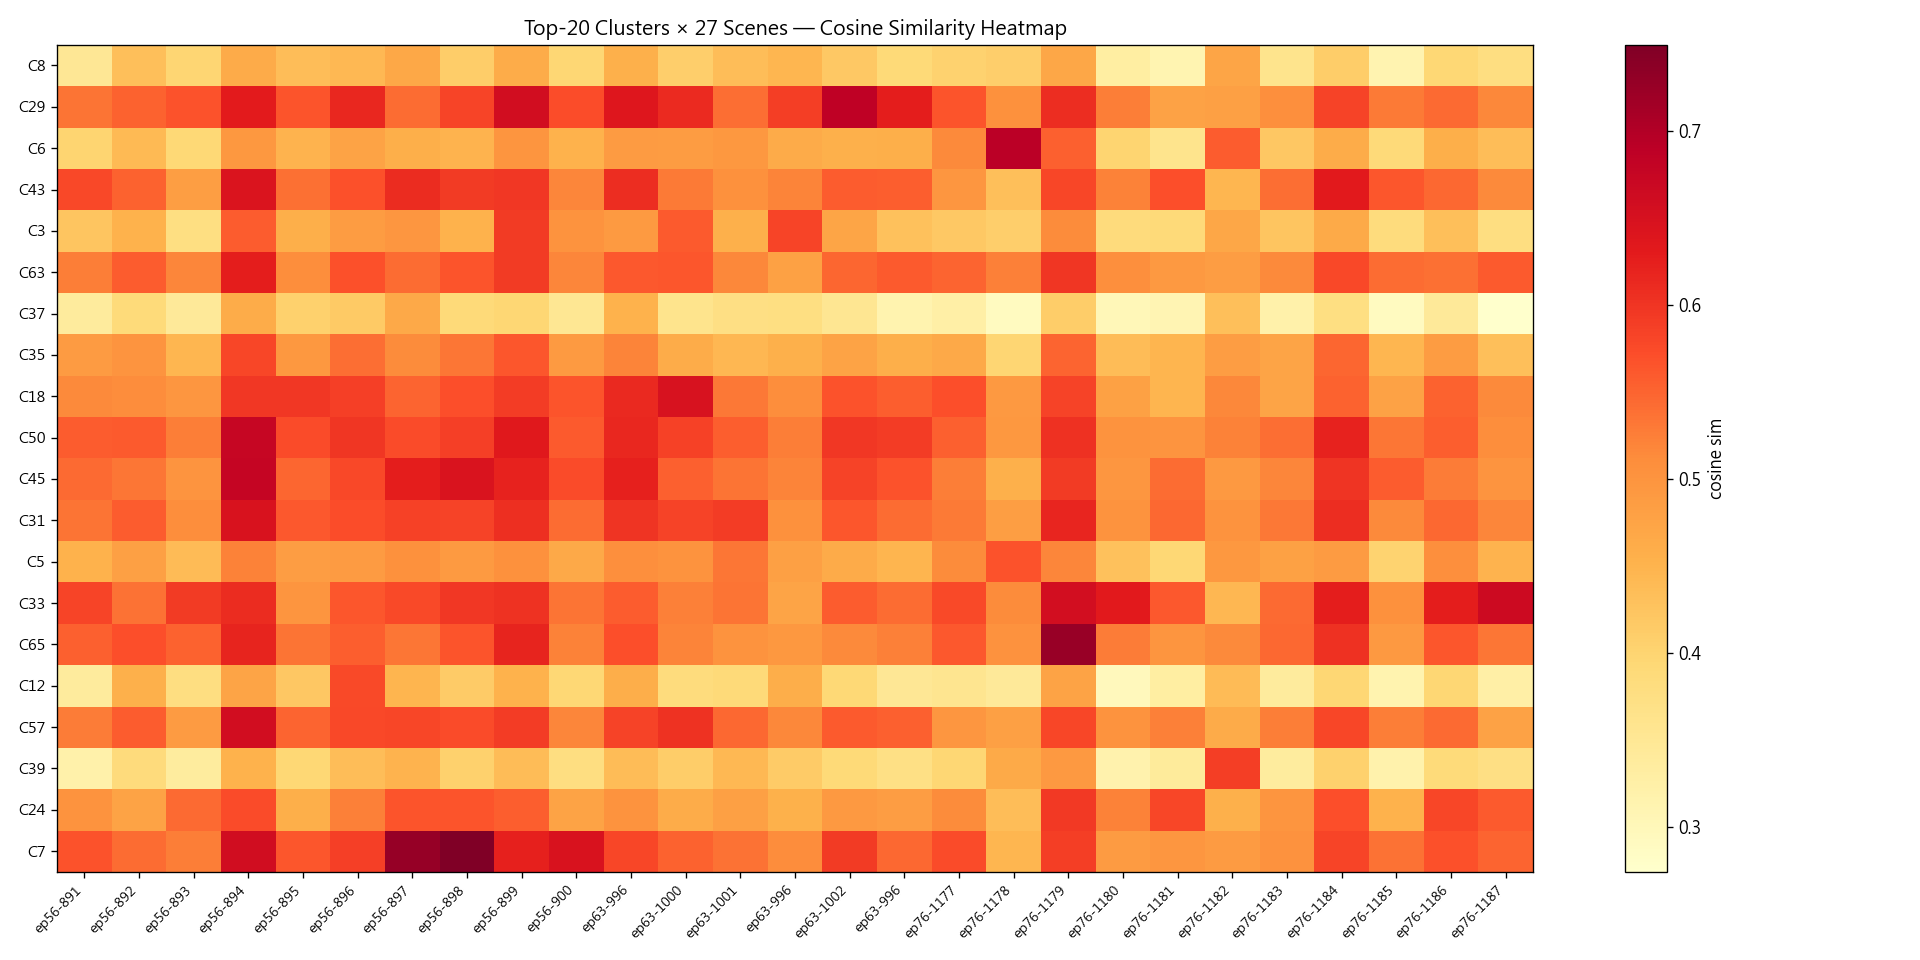

In [14]:
# 顯示 heatmap 圖（如果 PNG 已產出）
from IPython.display import Image, display
png_path = OUTPUT / "scene_heatmap.png"
if png_path.exists():
    display(Image(filename=str(png_path)))
else:
    print(f"{png_path} 不存在，請先跑 scene_heatmap.py")

---
## Part 9：角色迷因排行

每個 cluster 都已對應到最相似的劇本台詞（line-level），那台詞屬於某個角色。聚合後就能回答：

> **哪個角色「最會講迷因」？哪個角色的台詞引發最多互動？**

資料來源：`output/quote_classification.csv` 的 `matched_character` 欄位。

In [ ]:
# 角色維度聚合
character_rank = (
    quote_cls.groupby("matched_character")
    .agg(
        被迷因化次數 = ("cluster_id",  "count"),       # 多少個 cluster 對應到這個角色的台詞
        對應留言數   = ("size",        "sum"),         # 這些 cluster 加總的留言數
        總讚數       = ("likes_total", "sum"),         # 加總讚數
        最高讚      = ("likes_total", "max"),
        平均sim     = ("avg_top_sim", "mean"),
    )
    .reset_index()
    .rename(columns={"matched_character": "角色"})
)
character_rank["平均每群讚數"] = (character_rank["總讚數"] / character_rank["被迷因化次數"]).round(0).astype(int)
character_rank["平均sim"] = character_rank["平均sim"].round(3)

# 兩種排序視角
print("▌ 排行 1：被迷因化次數最多（哪個角色最常被改編）\n")
display(
    character_rank.sort_values("被迷因化次數", ascending=False)
    [["角色", "被迷因化次數", "總讚數", "平均每群讚數", "平均sim"]]
    .head(15)
    .reset_index(drop=True)
)

In [ ]:
print("▌ 排行 2：總讚數最高（哪個角色的迷因「最有影響力」）\n")
display(
    character_rank.sort_values("總讚數", ascending=False)
    [["角色", "被迷因化次數", "總讚數", "平均每群讚數", "最高讚"]]
    .head(15)
    .reset_index(drop=True)
)

print("\n▌ 排行 3：平均每群讚數（哪個角色「每出場必爆」）\n")
display(
    character_rank[character_rank["被迷因化次數"] >= 2]  # 至少出現 2 次才有意義
    .sort_values("平均每群讚數", ascending=False)
    [["角色", "被迷因化次數", "總讚數", "平均每群讚數", "最高讚"]]
    .head(15)
    .reset_index(drop=True)
)

In [ ]:
# 看某個角色名下都對應到哪些 cluster + 哪句台詞
CHARACTER = "皇帝"      # ← 改這裡，例如 "皇帝" / "甄嬛" / "安陵容" / "皇后" / "小允子"

char_clusters = (
    quote_cls[quote_cls["matched_character"] == CHARACTER]
    .sort_values("likes_total", ascending=False)
)

print(f"▌ {CHARACTER} 名下的 {len(char_clusters)} 個 cluster\n")
for _, r in char_clusters.head(10).iterrows():
    print(f"C{int(r['cluster_id']):>3}  size={int(r['size']):>3}  likes={int(r['likes_total']):>6}  "
          f"sim={r['avg_top_sim']:.3f}  type={r['type']}")
    print(f"      ╰ 對應台詞：{r['matched_character']}：{str(r['matched_line'])[:70]}")
    print(f"      ╰ 代表留言：{str(r['best_comment'])[:70]}")
    print()